# 🔬 synth10 Fine-Tuned Models — Custom Dataset Evaluation

This notebook evaluates **all synth10 fine-tuned model checkpoints** from a local `model_cache` against a **custom test dataset** downloaded from Google Drive.

## What this notebook does
1. Downloads a custom test dataset archive from Google Drive and extracts it
2. Downloads the synth10 fine-tuned model checkpoints archive from Google Drive
3. Loads each `.pth` checkpoint from `model_cache` and reconstructs the matching architecture
4. Evaluates all models on **100% of the test dataset** (no train/val split)
5. Reports the same full suite of classification metrics as the original benchmark

## Expected dataset format
The test dataset must follow **ImageFolder** layout:
```
test_dataset/
  airplane/  image1.png ...
  automobile/ ...
  bird/ ...
  cat/ ...
  deer/ ...
  dog/ ...
  frog/ ...
  horse/ ...
  ship/ ...
  truck/ ...
```
Class folder names must **exactly match** the CIFAR-10 class names.

## Model cache format
The model cache archive must contain `.pth` files named according to the convention used in the original benchmark:
```
{ModelName}_synth10_{loader_key}_scientific_ft_v1.pth
```
e.g. `ResNet-50_synth10_32_huy_scientific_ft_v1.pth`

In [1]:
# ============================================================
#  ⚙️  CONFIGURATION — edit these before running
# ============================================================

# Google Drive file ID for your TEST DATASET archive
# Accepted formats: .zip  |  .tar  |  .tar.gz  |  .tgz
TEST_DATASET_GDRIVE_ID = '116bz9S4foUCg9bqN9Yw_xXh67S032pLG'
TEST_DATASET_ARCHIVE   = 'sdxl_dataset.tar'   # local filename to save to (change extension to match)

# After extraction this should be the folder that contains class sub-folders directly.
# Leave as None to auto-detect (looks for the first directory that has CIFAR-10 sub-class folders).
TEST_DATASET_ROOT_OVERRIDE = None   # e.g. './my_test_dataset'

# Google Drive file ID for the MODEL CACHE archive
# The archive should contain the .pth checkpoint files (can be nested inside folders)
MODEL_CACHE_GDRIVE_ID  = '1ITH30Dlc8USMIXqj17PJilMF3_bSzfQC'
MODEL_CACHE_ARCHIVE    = 'model_cache.tar'    # local filename to save to

# Local directory where checkpoints will be extracted / already exist
MODEL_CACHE_DIR = './model_cache'

# ============================================================

In [2]:
# Install required packages (run once)
import subprocess, sys

packages = [
    'torch', 'torchvision',
    'timm>=0.9.0',
    'transformers>=4.35.0',
    'tqdm',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'pandas',
    'torchinfo',
    'huggingface_hub',
    'gdown',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)
print('✅ All packages installed.')

import warnings
warnings.filterwarnings('ignore')

✅ All packages installed.


In [3]:
import os, sys, json, shutil, zipfile, tarfile, re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
import torchvision.models as tvm

import timm
from transformers import AutoModelForImageClassification

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Ensure torchinfo is installed
try:
    import torchinfo
except ImportError:
    print("Installing 'torchinfo'...")
    import subprocess # Import subprocess here
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchinfo'])
    import torchinfo

from torchinfo import summary as torchinfo_summary

import gdown
import requests # Added requests for downloading from GitHub

import warnings
warnings.filterwarnings('ignore')

# ── Device ─────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Constants ──────────────────────────────────────────────────
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']
NUM_CLASSES     = 10
MODEL_CACHE_DIR = './model_cache' # Define MODEL_CACHE_DIR earlier or ensure it's imported
CACHE_DIR       = Path(MODEL_CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Plot style ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = sns.color_palette('tab20', 20)

print('✅ Imports complete.')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
✅ Imports complete.


In [4]:
# ── Official huyvnphan/PyTorch_CIFAR10 repo workflow ───────────────────────────

HUYVNPHAN_REPO_URL = "https://github.com/huyvnphan/PyTorch_CIFAR10.git"
HUYVNPHAN_REPO_ZIP_URL = "https://github.com/huyvnphan/PyTorch_CIFAR10/archive/refs/heads/master.zip"
HUYVNPHAN_SRC = "huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)"
HUYVNPHAN_GDRIVE_FILE_ID = "1PR1vNXH2yZlXTXSvKyXs1Uo2j4hbTdRw"

HUYVNPHAN_REPO_DIR = CACHE_DIR / "PyTorch_CIFAR10"

def stream_download(url, dst_path, chunk_size=2**20):
    dst_path = Path(dst_path)
    dst_path.parent.mkdir(parents=True, exist_ok=True)

    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))

        with open(dst_path, "wb") as f:
            pbar = tqdm(total=total, unit="B", unit_scale=True, desc=dst_path.name) if total > 0 else None
            for chunk in r.iter_content(chunk_size=chunk_size):
                if not chunk:
                    continue
                f.write(chunk)
                if pbar is not None:
                    pbar.update(len(chunk))
            if pbar is not None:
                pbar.close()

    return dst_path

def ensure_huyvnphan_repo():
    if HUYVNPHAN_REPO_DIR.exists():
        print(f"  ✅ Repo already present: {HUYVNPHAN_REPO_DIR}")
    else:
        try:
            print("  Cloning huyvnphan/PyTorch_CIFAR10 …")
            subprocess.check_call([
                "git", "clone", "--depth", "1",
                HUYVNPHAN_REPO_URL,
                str(HUYVNPHAN_REPO_DIR),
            ])
        except Exception as e:
            print(f"  git clone failed ({e}); downloading repository zip instead …")
            repo_zip = CACHE_DIR / "PyTorch_CIFAR10_master.zip"
            stream_download(HUYVNPHAN_REPO_ZIP_URL, repo_zip)

            with zipfile.ZipFile(repo_zip, "r") as zf:
                zf.extractall(CACHE_DIR)

            extracted = CACHE_DIR / "PyTorch_CIFAR10-master"
            if HUYVNPHAN_REPO_DIR.exists():
                shutil.rmtree(HUYVNPHAN_REPO_DIR)
            extracted.rename(HUYVNPHAN_REPO_DIR)

    repo_path = str(HUYVNPHAN_REPO_DIR.resolve())
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

def _fix_state_dict_layout(target_dir):
    """
    Makes sure weights end up in:
      <repo>/cifar10_models/state_dicts/*.pt
    even if the zip extracts into a nested folder.
    """
    target_dir = Path(target_dir)
    expected_dir = target_dir / "state_dicts"

    if expected_dir.exists() and any(expected_dir.glob("*.pt")):
        return expected_dir

    pt_files = list(target_dir.rglob("*.pt"))
    if not pt_files:
        return None

    expected_dir.mkdir(parents=True, exist_ok=True)

    for pt in pt_files:
        dst = expected_dir / pt.name
        if pt.resolve() != dst.resolve():
            shutil.copy2(pt, dst)

    return expected_dir if any(expected_dir.glob("*.pt")) else None

def ensure_huyvnphan_weights():
    state_dict_dir = HUYVNPHAN_REPO_DIR / "cifar10_models" / "state_dicts"
    if state_dict_dir.exists() and any(state_dict_dir.glob("*.pt")):
        print(f"  ✅ Weights already present in {state_dict_dir}")
        return state_dict_dir

    weights_zip = CACHE_DIR / "huyvnphan_state_dicts.zip"
    print("  Downloading official weights bundle with gdown …")

    try:
        url = f"https://drive.google.com/uc?id={HUYVNPHAN_GDRIVE_FILE_ID}"
        gdown.download(url, str(weights_zip), quiet=False, fuzzy=True)
    except Exception as e:
        print(f"  ❌ Failed to download huyvnphan/PyTorch_CIFAR10 weights with gdown: {e}")
        print("  Models from this source will be skipped.")
        return None

    if not weights_zip.exists():
        print("  ❌ Weights zip was not created.")
        print("  Models from this source will be skipped.")
        return None

    actual_size = weights_zip.stat().st_size
    if actual_size < 5 * 1024 * 1024:
        print(f"  ❌ Downloaded file is unexpectedly small ({actual_size / (1024*1024):.2f} MB).")
        print("  Models from this source will be skipped.")
        return None

    target_dir = HUYVNPHAN_REPO_DIR / "cifar10_models"
    target_dir.mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(weights_zip, "r") as zf:
            zf.extractall(target_dir)
    except zipfile.BadZipFile:
        print(f"  ❌ Downloaded file {weights_zip.name} is not a valid zip file.")
        print("  Models from this source will be skipped.")
        return None

    fixed_dir = _fix_state_dict_layout(target_dir)
    if fixed_dir is None:
        print(f"  ❌ Expected extracted weights under {state_dict_dir}, but none were found.")
        print("  Models from this source will be skipped.")
        return None

    print(f"  ✅ Extracted weights to {fixed_dir}")
    return fixed_dir

ensure_huyvnphan_repo()
weights_loaded = ensure_huyvnphan_weights()

if weights_loaded:
    print(f'✅ huyvnphan/PyTorch_CIFAR10 setup complete. Weights available in {weights_loaded}')
else:
    print('  Skipping huyvnphan/PyTorch_CIFAR10 models due to setup issues.')

  Cloning huyvnphan/PyTorch_CIFAR10 …
  ❌ Failed to download huyvnphan/PyTorch_CIFAR10 weights with gdown: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1PR1vNXH2yZlXTXSvKyXs1Uo2j4hbTdRw

but Gdown can't. Please check connections and permissions.
  Models from this source will be skipped.
  Skipping huyvnphan/PyTorch_CIFAR10 models due to setup issues.


## 📥 1 · Download & Extract Test Dataset

In [5]:
def download_from_gdrive(file_id, output_path, description='file'):
    """Download a file from Google Drive using gdown."""
    output_path = Path(output_path)
    if output_path.exists():
        print(f'  ✅ {description} already downloaded: {output_path}')
        return output_path
    print(f'  Downloading {description} from Google Drive (id={file_id}) …')
    gdown.download(id=file_id, output=str(output_path), quiet=False, fuzzy=True)
    if not output_path.exists():
        raise FileNotFoundError(f'Download failed — {output_path} was not created.')
    print(f'  ✅ Downloaded: {output_path} ({output_path.stat().st_size / 1e6:.1f} MB)')
    return output_path


def extract_archive(archive_path, dest_dir='.'):
    """Extract a .zip, .tar, .tar.gz, or .tgz archive to dest_dir."""
    archive_path = Path(archive_path)
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)
    name = archive_path.name.lower()
    print(f'  Extracting {archive_path.name} → {dest_dir} …')
    if name.endswith('.zip'):
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(dest_dir)
    elif name.endswith(('.tar', '.tar.gz', '.tgz', '.tar.bz2', '.tar.xz')):
        with tarfile.open(archive_path, 'r:*') as tf:
            tf.extractall(dest_dir)
    else:
        raise ValueError(f'Unsupported archive format: {archive_path.name}')
    print('  ✅ Extraction complete.')


def find_imagefolder_root(base_dir, class_names):
    """
    Walk base_dir to find the shallowest directory whose immediate
    children include ALL class_names as sub-directories.
    """
    base_dir = Path(base_dir)
    class_set = set(class_names)
    # BFS by depth
    from collections import deque
    queue = deque([base_dir])
    while queue:
        current = queue.popleft()
        try:
            subdirs = {p.name for p in current.iterdir() if p.is_dir()}
        except PermissionError:
            continue
        if class_set.issubset(subdirs):
            return current
        for p in sorted(current.iterdir()):
            if p.is_dir():
                queue.append(p)
    return None


# ── Download test dataset ──────────────────────────────────────
test_archive = download_from_gdrive(
    TEST_DATASET_GDRIVE_ID,
    TEST_DATASET_ARCHIVE,
    description='test dataset',
)
extract_archive(test_archive, dest_dir='.')

# ── Locate the ImageFolder root ────────────────────────────────
if TEST_DATASET_ROOT_OVERRIDE:
    TEST_ROOT = Path(TEST_DATASET_ROOT_OVERRIDE)
    assert TEST_ROOT.exists(), f'Override path does not exist: {TEST_ROOT}'
else:
    TEST_ROOT = find_imagefolder_root('.', CIFAR10_CLASSES)

if TEST_ROOT is None:
    raise FileNotFoundError(
        'Could not find an ImageFolder-compatible directory with all 10 CIFAR-10 '
        'class sub-folders. Please set TEST_DATASET_ROOT_OVERRIDE manually.'
    )

print(f'\n✅ Test dataset root: {TEST_ROOT.resolve()}')
for cls in CIFAR10_CLASSES:
    n = len(list((TEST_ROOT / cls).glob('*.*')))
    print(f'   {cls:12s}: {n} images')

Downloading...
From (original): https://drive.google.com/uc?id=116bz9S4foUCg9bqN9Yw_xXh67S032pLG
From (redirected): https://drive.google.com/uc?id=116bz9S4foUCg9bqN9Yw_xXh67S032pLG&confirm=t&uuid=eb1aff0d-3d47-4c3c-9243-f2cd7d7ee297
To: /content/sdxl_dataset.tar
100%|██████████| 63.3M/63.3M [00:01<00:00, 40.6MB/s]


  ✅ Downloaded: sdxl_dataset.tar (63.3 MB)
  Extracting sdxl_dataset.tar → . …
  ✅ Extraction complete.

✅ Test dataset root: /content/sdxl10
   airplane    : 2000 images
   automobile  : 2000 images
   bird        : 2000 images
   cat         : 2000 images
   deer        : 2000 images
   dog         : 2000 images
   frog        : 2000 images
   horse       : 2000 images
   ship        : 2000 images
   truck       : 2000 images


## 📥 2 · Download & Extract Model Cache

In [6]:
# ── Download model checkpoints ─────────────────────────────────
model_archive = download_from_gdrive(
    MODEL_CACHE_GDRIVE_ID,
    MODEL_CACHE_ARCHIVE,
    description='model cache',
)
extract_archive(model_archive, dest_dir=CACHE_DIR)

# Flatten: if the archive extracted into a sub-folder, move .pth files up
pth_files = list(CACHE_DIR.rglob('*.pth'))
for pth in pth_files:
    dest = CACHE_DIR / pth.name
    if pth.resolve() != dest.resolve():
        shutil.copy2(pth, dest)

pth_files = sorted(CACHE_DIR.glob('*.pth'))
print(f'\n✅ Found {len(pth_files)} .pth checkpoint(s) in {CACHE_DIR}:')
for p in pth_files:
    print(f'   {p.name}  ({p.stat().st_size / 1e6:.1f} MB)')

Downloading...
From (original): https://drive.google.com/uc?id=1ITH30Dlc8USMIXqj17PJilMF3_bSzfQC
From (redirected): https://drive.google.com/uc?id=1ITH30Dlc8USMIXqj17PJilMF3_bSzfQC&confirm=t&uuid=a902e217-d6f3-401d-8ebf-a009779125ec
To: /content/model_cache.tar
100%|██████████| 2.34G/2.34G [00:40<00:00, 58.2MB/s]


  ✅ Downloaded: model_cache.tar (2335.3 MB)
  Extracting model_cache.tar → model_cache …
  ✅ Extraction complete.

✅ Found 17 .pth checkpoint(s) in model_cache:
   ConvNeXt-Base_synth10_224_scientific_ft_v1.pth  (350.4 MB)
   ConvNeXtV2-Base_synth10_224_scientific_ft_v1.pth  (351.0 MB)
   DenseNet-121_synth10_32_huy_scientific_ft_v1.pth  (28.5 MB)
   DenseNet-169_synth10_32_huy_scientific_ft_v1.pth  (51.0 MB)
   DenseNet-201_synth10_224_scientific_ft_v1.pth  (73.9 MB)
   EfficientNet-B0_synth10_224_scientific_ft_v1.pth  (16.4 MB)
   EfficientNetV2-S_synth10_224_scientific_ft_v1.pth  (81.7 MB)
   GoogLeNet_synth10_32_huy_scientific_ft_v1.pth  (22.2 MB)
   InceptionV3_synth10_32_huy_scientific_ft_v1.pth  (86.9 MB)
   MNASNet-1.0_synth10_224_scientific_ft_v1.pth  (12.7 MB)
   MobileNetV2_synth10_32_scientific_ft_v1.pth  (9.2 MB)
   RegNetY-8GF_synth10_224_scientific_ft_v1.pth  (150.1 MB)
   ResNet-152_synth10_224_scientific_ft_v1.pth  (233.6 MB)
   ResNet-50_synth10_32_huy_scientific_ft_v

## 🔧 3 · Transform Pipelines & Dataset Loaders

In [7]:
# ── Three evaluation transforms matching the original benchmark ──
tf_32 = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std =[0.2023, 0.1994, 0.2010]),
])

tf_32_huy = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465],
                std =[0.2471, 0.2435, 0.2616]),
])

tf_224 = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

BS  = 128 if device.type == 'cuda' else 32
NW  = 0
PIN = (device.type == 'cuda')

def make_loader(root, transform):
    ds = torchvision.datasets.ImageFolder(root, transform=transform)
    # Verify class order matches CIFAR-10
    observed = [cls for cls, _ in sorted(ds.class_to_idx.items(), key=lambda kv: kv[1])]
    if observed != CIFAR10_CLASSES:
        raise ValueError(
            f'Class order mismatch!\nExpected: {CIFAR10_CLASSES}\nObserved: {observed}'
        )
    return DataLoader(ds, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)

loader_32     = make_loader(TEST_ROOT, tf_32)
loader_32_huy = make_loader(TEST_ROOT, tf_32_huy)
loader_224    = make_loader(TEST_ROOT, tf_224)

TEST_LOADERS = {'32': loader_32, '32_huy': loader_32_huy, '224': loader_224}

total_images = len(loader_32.dataset)
print(f'✅ Test dataset loaded: {total_images} images across {NUM_CLASSES} classes.')
print(f'   Loader sizes — 32px: {len(loader_32.dataset)} | '
      f'32px-huy: {len(loader_32_huy.dataset)} | '
      f'224px: {len(loader_224.dataset)}')

✅ Test dataset loaded: 20000 images across 10 classes.
   Loader sizes — 32px: 20000 | 32px-huy: 20000 | 224px: 20000


## 🤖 4 · Architecture Definitions

Each architecture that was fine-tuned in the original benchmark is recreated here **without pretrained weights** — the saved checkpoint weights are loaded on top.

In [8]:
def replace_head(model, num_classes=10):
    """Replace the final classification head to match num_classes."""
    if hasattr(model, 'reset_classifier'):
        model.reset_classifier(num_classes)
        return model
    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    if hasattr(model, 'classifier'):
        c = model.classifier
        if isinstance(c, nn.Linear):
            model.classifier = nn.Linear(c.in_features, num_classes)
            return model
        if isinstance(c, nn.Sequential):
            layers = list(c.children())
            for idx in range(len(layers) - 1, -1, -1):
                if isinstance(layers[idx], nn.Linear):
                    layers[idx] = nn.Linear(layers[idx].in_features, num_classes)
                    model.classifier = nn.Sequential(*layers)
                    return model
    if hasattr(model, 'head') and isinstance(model.head, nn.Linear):
        model.head = nn.Linear(model.head.in_features, num_classes)
        return model
    if hasattr(model, 'heads') and hasattr(model.heads, 'head') and isinstance(model.heads.head, nn.Linear):
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        return model
    raise ValueError(f'Could not replace classifier head for: {type(model)}')


# ── Architecture factory ────────────────────────────────────────
# Maps display name → (loader_key, build_fn)
# build_fn returns a freshly initialised model with a 10-class head,
# ready to receive saved state_dict weights.

def _build_chenyaofo(hub_name):
    """Load a CIFAR-native chenyaofo model architecture (no pretrained weights)."""
    m = torch.hub.load('chenyaofo/pytorch-cifar-models', hub_name,
                       pretrained=False, trust_repo=True, verbose=False)
    return m

def _build_huyvnphan_resnet50():
    from cifar10_models.resnet import resnet50
    return resnet50(pretrained=False)

def _build_huyvnphan_densenet121():
    from cifar10_models.densenet import densenet121
    return densenet121(pretrained=False)

def _build_huyvnphan_densenet169():
    from cifar10_models.densenet import densenet169
    return densenet169(pretrained=False)

def _build_huyvnphan_googlenet():
    from cifar10_models.googlenet import googlenet
    return googlenet(pretrained=False)

def _build_huyvnphan_inceptionv3():
    from cifar10_models.inception import inception_v3
    return inception_v3(pretrained=False)

def _build_vit():
    m = AutoModelForImageClassification.from_pretrained(
        'aaraki/vit-base-patch16-224-in21k-finetuned-cifar10')
    return m

def _build_swin():
    m = AutoModelForImageClassification.from_pretrained(
        'Weili/swin-base-patch4-window7-224-in22k-finetuned-cifar10')
    return m

def _tv(cls, weights_cls):
    """Build a torchvision model with head replaced."""
    m = cls(weights=None)
    replace_head(m, NUM_CLASSES)
    return m

ARCH_REGISTRY = {
    # name                    : (loader_key,  build_fn)
    'VGG19-BN'               : ('32',         lambda: _build_chenyaofo('cifar10_vgg19_bn')),
    'MobileNetV2'            : ('32',         lambda: _build_chenyaofo('cifar10_mobilenetv2_x1_0')),
    'ResNet-50'              : ('32_huy',     _build_huyvnphan_resnet50),
    'DenseNet-121'           : ('32_huy',     _build_huyvnphan_densenet121),
    'DenseNet-169'           : ('32_huy',     _build_huyvnphan_densenet169),
    'GoogLeNet'              : ('32_huy',     _build_huyvnphan_googlenet),
    'InceptionV3'            : ('32_huy',     _build_huyvnphan_inceptionv3),
    'ViT-Base/16'            : ('224',        _build_vit),
    'Swin-Base'              : ('224',        _build_swin),
    'ResNet-152'             : ('224',        lambda: _tv(tvm.resnet152, None)),
    'DenseNet-201'           : ('224',        lambda: _tv(tvm.densenet201, None)),
    'MNASNet-1.0'            : ('224',        lambda: _tv(tvm.mnasnet1_0, None)),
    'EfficientNet-B0'        : ('224',        lambda: _tv(tvm.efficientnet_b0, None)),
    'EfficientNetV2-S'       : ('224',        lambda: _tv(tvm.efficientnet_v2_s, None)),
    'RegNetY-8GF'            : ('224',        lambda: _tv(tvm.regnet_y_8gf, None)),
    'ConvNeXt-Base'          : ('224',        lambda: _tv(tvm.convnext_base, None)),
    'ConvNeXtV2-Base'        : ('224',        lambda: timm.create_model('convnextv2_base', pretrained=False, num_classes=NUM_CLASSES)),
}

print(f'✅ Architecture registry ready ({len(ARCH_REGISTRY)} architectures defined).')

✅ Architecture registry ready (17 architectures defined).


## 📂 5 · Discover & Load Checkpoints from model_cache

In [9]:
# ── Parse checkpoint filenames ──────────────────────────────────
# Expected naming: {ModelName}_synth10_{loader_key}_scientific_ft_v1.pth
# We also handle the CIFAR-10 fallback format: {ModelName}_scientific_ft_v3.pth

CHECKPOINT_PATTERN = re.compile(
    r'^(?P<model_name>.+?)_synth10_(?P<loader_key>[^_]+(?:_[^_]+)?)_scientific_ft_v1\.pth$'
)

def safe_model_name_to_display(safe_name):
    """Convert the filesystem-safe name back to the display name used in ARCH_REGISTRY."""
    # Reverse: spaces were replaced by underscores, '/' by '-'
    # Try exact lookup first, then heuristic
    for display_name in ARCH_REGISTRY:
        candidate = display_name.replace('/', '-').replace(' ', '_')
        if candidate == safe_name:
            return display_name
    return safe_name  # fallback: return as-is


discovered = []   # list of (display_name, loader_key, checkpoint_path)

for pth in sorted(CACHE_DIR.glob('*.pth')):
    m = CHECKPOINT_PATTERN.match(pth.name)
    if m:
        safe_name  = m.group('model_name')
        loader_key = m.group('loader_key')
        display_name = safe_model_name_to_display(safe_name)
        discovered.append((display_name, loader_key, pth))

if not discovered:
    raise RuntimeError(
        f'No synth10 fine-tuned checkpoints found in {CACHE_DIR}.\n'
        'Expected files matching: {{ModelName}}_synth10_{{loader}}_scientific_ft_v1.pth'
    )

print(f'\n✅ Discovered {len(discovered)} synth10 fine-tuned checkpoint(s):')
for dname, lkey, ckpt in discovered:
    known = '✅' if dname in ARCH_REGISTRY else '⚠️  (not in ARCH_REGISTRY)'
    print(f'  {known}  {dname:30s}  loader={lkey:8s}  {ckpt.name}')


✅ Discovered 17 synth10 fine-tuned checkpoint(s):
  ✅  ConvNeXt-Base                   loader=224       ConvNeXt-Base_synth10_224_scientific_ft_v1.pth
  ✅  ConvNeXtV2-Base                 loader=224       ConvNeXtV2-Base_synth10_224_scientific_ft_v1.pth
  ✅  DenseNet-121                    loader=32_huy    DenseNet-121_synth10_32_huy_scientific_ft_v1.pth
  ✅  DenseNet-169                    loader=32_huy    DenseNet-169_synth10_32_huy_scientific_ft_v1.pth
  ✅  DenseNet-201                    loader=224       DenseNet-201_synth10_224_scientific_ft_v1.pth
  ✅  EfficientNet-B0                 loader=224       EfficientNet-B0_synth10_224_scientific_ft_v1.pth
  ✅  EfficientNetV2-S                loader=224       EfficientNetV2-S_synth10_224_scientific_ft_v1.pth
  ✅  GoogLeNet                       loader=32_huy    GoogLeNet_synth10_32_huy_scientific_ft_v1.pth
  ✅  InceptionV3                     loader=32_huy    InceptionV3_synth10_32_huy_scientific_ft_v1.pth
  ✅  MNASNet-1.0              

In [10]:
# ── Load each checkpoint ────────────────────────────────────────
MODEL_REGISTRY = {}   # name → {'model', 'loader', 'params_M', 'ckpt_path'}

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    return total / 1e6


for display_name, loader_key, ckpt_path in discovered:
    if display_name not in ARCH_REGISTRY:
        print(f'  ⚠️  Skipping {display_name} — not in ARCH_REGISTRY. '
              f'Add it manually if needed.')
        continue

    expected_loader = ARCH_REGISTRY[display_name][0]
    if loader_key != expected_loader:
        print(f'  ⚠️  {display_name}: checkpoint loader_key={loader_key} '
              f'differs from registry expected={expected_loader}. Using checkpoint value.')
    # Use the loader key embedded in the filename (more reliable)
    actual_loader_key = loader_key

    try:
        print(f'  Loading {display_name} …')
        build_fn = ARCH_REGISTRY[display_name][1]
        model = build_fn()

        ckpt = torch.load(ckpt_path, map_location=device)
        state_dict = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
        model.load_state_dict(state_dict, strict=True)
        model = model.to(device).eval()

        params_M = count_params(model)
        MODEL_REGISTRY[display_name] = {
            'model': model,
            'loader': actual_loader_key,
            'params_M': round(params_M, 2),
            'ckpt_path': str(ckpt_path),
        }
        print(f'    ✅ {display_name:35s} | {params_M:.1f}M params | loader={actual_loader_key}')

    except Exception as e:
        print(f'  ❌ Failed to load {display_name}: {e}')

print(f'\n✅ Successfully loaded {len(MODEL_REGISTRY)} / {len(discovered)} models.')

  Loading ConvNeXt-Base …
    ✅ ConvNeXt-Base                       | 87.6M params | loader=224
  Loading ConvNeXtV2-Base …
    ✅ ConvNeXtV2-Base                     | 87.7M params | loader=224
  Loading DenseNet-121 …
    ✅ DenseNet-121                        | 7.0M params | loader=32_huy
  Loading DenseNet-169 …
    ✅ DenseNet-169                        | 12.5M params | loader=32_huy
  Loading DenseNet-201 …
    ✅ DenseNet-201                        | 18.1M params | loader=224
  Loading EfficientNet-B0 …
    ✅ EfficientNet-B0                     | 4.0M params | loader=224
  Loading EfficientNetV2-S …
    ✅ EfficientNetV2-S                    | 20.2M params | loader=224
  Loading GoogLeNet …
    ✅ GoogLeNet                           | 5.5M params | loader=32_huy
  Loading InceptionV3 …
    ✅ InceptionV3                         | 21.6M params | loader=32_huy
  Loading MNASNet-1.0 …
    ✅ MNASNet-1.0                         | 3.1M params | loader=224
  Loading MobileNetV2 …
Downloading:

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/348M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/348M [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

    ✅ ViT-Base/16                         | 85.8M params | loader=224

✅ Successfully loaded 17 / 17 models.


## 🧪 6 · Utility Functions (Evaluation)

In [11]:
def forward_logits(model, x):
    out = model(x)
    return out.logits if hasattr(out, 'logits') else out


def build_confusion_metrics_df(cm, class_names):
    rows = []
    total = cm.sum()
    for i, cls_name in enumerate(class_names):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - tp - fn - fp)
        sensitivity = 0.0 if (tp + fn) == 0 else tp / (tp + fn)
        specificity = 0.0 if (tn + fp) == 0 else tn / (tn + fp)
        precision   = 0.0 if (tp + fp) == 0 else tp / (tp + fp)
        npv         = 0.0 if (tn + fn) == 0 else tn / (tn + fn)
        fpr         = 0.0 if (fp + tn) == 0 else fp / (fp + tn)
        fnr         = 0.0 if (fn + tp) == 0 else fn / (fn + tp)
        rows.append({
            'Class': cls_name,
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'Precision (%)': precision * 100,
            'Recall / Sensitivity (%)': sensitivity * 100,
            'Specificity (%)': specificity * 100,
            'NPV (%)': npv * 100,
            'FPR (%)': fpr * 100,
            'FNR (%)': fnr * 100,
            'Support': int(cm[i, :].sum()),
        })
    return pd.DataFrame(rows)


def extract_top_confusions(cm, class_names, top_n=10):
    rows = []
    for i in range(len(class_names)):
        row_total = cm[i].sum()
        if row_total == 0:
            continue
        for j in range(len(class_names)):
            if i == j:
                continue
            count = int(cm[i, j])
            if count == 0:
                continue
            rows.append({
                'True Class': class_names[i],
                'Predicted As': class_names[j],
                'Count': count,
                'Rate (%)': count / row_total * 100,
            })
    if not rows:
        return pd.DataFrame(columns=['True Class', 'Predicted As', 'Count', 'Rate (%)'])
    return (
        pd.DataFrame(rows)
        .sort_values(['Rate (%)', 'Count'], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


@torch.no_grad()
def evaluate(model, loader, model_name='model', desc=None):
    """Full scientific multiclass evaluation — identical metric suite to the original benchmark."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc=desc or f'Eval {model_name}', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        logits = forward_logits(model, imgs)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds  = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)
    all_probs  = np.asarray(all_probs)

    y_true_bin = label_binarize(all_labels, classes=np.arange(NUM_CLASSES))
    cm         = confusion_matrix(all_labels, all_preds, labels=np.arange(NUM_CLASSES))
    cm_norm    = cm.astype(np.float64) / np.clip(cm.sum(axis=1, keepdims=True), 1, None) * 100.0

    acc      = accuracy_score(all_labels, all_preds) * 100
    bal_acc  = balanced_accuracy_score(all_labels, all_preds) * 100

    prec_macro, rec_macro, f1_macro, _         = precision_recall_fscore_support(all_labels, all_preds, average='macro',    zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    prec_micro, rec_micro, f1_micro, _          = precision_recall_fscore_support(all_labels, all_preds, average='micro',    zero_division=0)

    roc_auc_macro    = roc_auc_score(y_true_bin, all_probs, multi_class='ovr', average='macro')    * 100
    roc_auc_weighted = roc_auc_score(y_true_bin, all_probs, multi_class='ovr', average='weighted') * 100
    pr_auc_macro     = average_precision_score(y_true_bin, all_probs, average='macro')    * 100
    pr_auc_weighted  = average_precision_score(y_true_bin, all_probs, average='weighted') * 100

    mcc   = matthews_corrcoef(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)

    cls_prec, cls_rec, cls_f1, cls_support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=np.arange(NUM_CLASSES), zero_division=0
    )

    confusion_metrics_df = build_confusion_metrics_df(cm, CIFAR10_CLASSES)
    per_class_rows = []
    for i, cls_name in enumerate(CIFAR10_CLASSES):
        per_class_rows.append({
            'Class': cls_name,
            'Precision (%)': cls_prec[i] * 100,
            'Recall / Sensitivity (%)': cls_rec[i] * 100,
            'Specificity (%)': float(confusion_metrics_df.loc[i, 'Specificity (%)']),
            'NPV (%)': float(confusion_metrics_df.loc[i, 'NPV (%)']),
            'FPR (%)': float(confusion_metrics_df.loc[i, 'FPR (%)']),
            'FNR (%)': float(confusion_metrics_df.loc[i, 'FNR (%)']),
            'F1 Score (%)': cls_f1[i] * 100,
            'Support': int(cls_support[i]),
        })

    per_class_df   = pd.DataFrame(per_class_rows)
    class_report   = classification_report(all_labels, all_preds, target_names=CIFAR10_CLASSES, digits=4, zero_division=0)

    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro) * 100

    return dict(
        accuracy=acc,
        balanced_accuracy=bal_acc,
        precision_macro=prec_macro * 100,
        recall_macro=rec_macro * 100,
        f1_macro=f1_macro * 100,
        precision_weighted=prec_weighted * 100,
        recall_weighted=rec_weighted * 100,
        f1_weighted=f1_weighted * 100,
        precision_micro=prec_micro * 100,
        recall_micro=rec_micro * 100,
        f1_micro=f1_micro * 100,
        specificity_macro=confusion_metrics_df['Specificity (%)'].mean(),
        npv_macro=confusion_metrics_df['NPV (%)'].mean(),
        fpr_macro=confusion_metrics_df['FPR (%)'].mean(),
        fnr_macro=confusion_metrics_df['FNR (%)'].mean(),
        roc_auc_macro_ovr=roc_auc_macro,
        roc_auc_weighted_ovr=roc_auc_weighted,
        roc_auc_micro=roc_auc_micro,
        pr_auc_macro=pr_auc_macro,
        pr_auc_weighted=pr_auc_weighted,
        mcc=mcc,
        cohen_kappa=kappa,
        confusion_matrix=cm,
        confusion_matrix_norm=cm_norm,
        confusion_metrics=confusion_metrics_df,
        per_class_metrics=per_class_df,
        class_report=class_report,
        top_confusions=extract_top_confusions(cm, CIFAR10_CLASSES, top_n=10),
        preds=all_preds,
        labels=all_labels,
        probs=all_probs,
        y_true_bin=y_true_bin,
        roc_curve_micro=(fpr_micro, tpr_micro),
    )

print('✅ Evaluation utilities ready.')

✅ Evaluation utilities ready.


## 📊 7 · Evaluate All synth10 Fine-Tuned Models on the Custom Test Dataset

In [12]:
EVAL_RESULTS = {}

print('=' * 100)
print('  Evaluating all synth10 fine-tuned models on the custom test dataset (100% test, no split)')
print('=' * 100)

for name, info in MODEL_REGISTRY.items():
    loader_key = info['loader']
    if loader_key not in TEST_LOADERS:
        print(f'  ⚠️  {name}: loader_key={loader_key} not available, skipping.')
        continue

    loader = TEST_LOADERS[loader_key]
    model  = info['model']

    res = evaluate(model, loader, model_name=name)
    res['params_M']   = info['params_M']
    res['loader_key'] = loader_key
    EVAL_RESULTS[name] = res

    print(
        f'  {name:40s} '
        f'Acc={res["accuracy"]:.2f}%  '
        f'F1-macro={res["f1_macro"]:.2f}%  '
        f'BalAcc={res["balanced_accuracy"]:.2f}%  '
        f'ROC-AUC={res["roc_auc_macro_ovr"]:.2f}%  '
        f'MCC={res["mcc"]:.4f}'
    )

print(f'\n✅ Evaluation complete for {len(EVAL_RESULTS)} models.')

  Evaluating all synth10 fine-tuned models on the custom test dataset (100% test, no split)


Eval ConvNeXt-Base:   0%|          | 0/157 [00:00<?, ?it/s]

  ConvNeXt-Base                            Acc=98.67%  F1-macro=98.67%  BalAcc=98.68%  ROC-AUC=99.95%  MCC=0.9853


Eval ConvNeXtV2-Base:   0%|          | 0/157 [00:00<?, ?it/s]

  ConvNeXtV2-Base                          Acc=84.81%  F1-macro=85.13%  BalAcc=84.81%  ROC-AUC=98.29%  MCC=0.8334


...

  Swin-Base                                Acc=98.22%  F1-macro=98.22%  BalAcc=98.23%  ROC-AUC=99.96%  MCC=0.9803


Eval VGG19-BN:   0%|          | 0/157 [00:00<?, ?it/s]

  VGG19-BN                                 Acc=90.81%  F1-macro=90.87%  BalAcc=90.80%  ROC-AUC=99.16%  MCC=0.8983


Eval ViT-Base/16:   0%|          | 0/157 [00:00<?, ?it/s]

  ViT-Base/16                              Acc=98.45%  F1-macro=98.44%  BalAcc=98.45%  ROC-AUC=99.96%  MCC=0.9827

✅ Evaluation complete for 17 models.


## 📋 8 · Results Table

In [13]:
CORE_METRIC_COLS = [
    'Accuracy (%)', 'Balanced Accuracy (%)', 'Precision Macro (%)', 'Recall Macro (%)',
    'F1 Macro (%)', 'F1 Weighted (%)', 'Specificity Macro (%)', 'NPV Macro (%)',
    'FPR Macro (%)', 'FNR Macro (%)', 'ROC AUC Macro OVR (%)', 'ROC AUC Micro (%)',
    'PR AUC Macro (%)', 'MCC', "Cohen's Kappa",
]

rows = []
for model_name, r in EVAL_RESULTS.items():
    rows.append({
        'Model': model_name,
        'Params (M)': r['params_M'],
        'Loader': r['loader_key'],
        'Accuracy (%)': round(r['accuracy'], 2),
        'Balanced Accuracy (%)': round(r['balanced_accuracy'], 2),
        'Precision Macro (%)': round(r['precision_macro'], 2),
        'Recall Macro (%)': round(r['recall_macro'], 2),
        'F1 Macro (%)': round(r['f1_macro'], 2),
        'F1 Weighted (%)': round(r['f1_weighted'], 2),
        'Specificity Macro (%)': round(r['specificity_macro'], 2),
        'NPV Macro (%)': round(r['npv_macro'], 2),
        'FPR Macro (%)': round(r['fpr_macro'], 2),
        'FNR Macro (%)': round(r['fnr_macro'], 2),
        'ROC AUC Macro OVR (%)': round(r['roc_auc_macro_ovr'], 2),
        'ROC AUC Micro (%)': round(r['roc_auc_micro'], 2),
        'PR AUC Macro (%)': round(r['pr_auc_macro'], 2),
        'MCC': round(r['mcc'], 4),
        "Cohen's Kappa": round(r['cohen_kappa'], 4),
    })

RESULTS_DF = pd.DataFrame(rows)

# Rank within this evaluation
RESULTS_DF['Rank Accuracy'] = RESULTS_DF['Accuracy (%)'].rank(ascending=False, method='min')
RESULTS_DF['Rank F1 Macro'] = RESULTS_DF['F1 Macro (%)'].rank(ascending=False, method='min')
RESULTS_DF['Rank ROC AUC']  = RESULTS_DF['ROC AUC Macro OVR (%)'].rank(ascending=False, method='min')
RESULTS_DF['Mean Rank']     = RESULTS_DF[['Rank Accuracy', 'Rank F1 Macro', 'Rank ROC AUC']].mean(axis=1)
RESULTS_DF = RESULTS_DF.sort_values(['Mean Rank', 'F1 Macro (%)', 'Accuracy (%)'],
                                     ascending=[True, False, False]).reset_index(drop=True)

csv_path = 'synth10_finetuned_custom_test_evaluation.csv'
RESULTS_DF.to_csv(csv_path, index=False)
print(f'✅ Saved: {csv_path}\n')

display(
    RESULTS_DF[['Model', 'Params (M)'] + CORE_METRIC_COLS + ['Mean Rank']]
    .style
    .format({
        'Params (M)': '{:.1f}',
        'Accuracy (%)': '{:.2f}',
        'Balanced Accuracy (%)': '{:.2f}',
        'Precision Macro (%)': '{:.2f}',
        'Recall Macro (%)': '{:.2f}',
        'F1 Macro (%)': '{:.2f}',
        'F1 Weighted (%)': '{:.2f}',
        'Specificity Macro (%)': '{:.2f}',
        'NPV Macro (%)': '{:.2f}',
        'FPR Macro (%)': '{:.2f}',
        'FNR Macro (%)': '{:.2f}',
        'ROC AUC Macro OVR (%)': '{:.2f}',
        'ROC AUC Micro (%)': '{:.2f}',
        'PR AUC Macro (%)': '{:.2f}',
        'MCC': '{:.4f}',
        "Cohen's Kappa": '{:.4f}',
        'Mean Rank': '{:.2f}',
    })
    .background_gradient(subset=['Accuracy (%)', 'F1 Macro (%)', 'ROC AUC Macro OVR (%)'], cmap='RdYlGn')
    .background_gradient(subset=['Mean Rank'], cmap='RdYlGn_r')
    .set_caption('Synth10 Fine-Tuned Models — Custom Test Dataset Evaluation (ranked by Mean Rank)')
)

✅ Saved: synth10_finetuned_custom_test_evaluation.csv



,Model,Params (M),Accuracy (%),Balanced Accuracy (%),Precision Macro (%),Recall Macro (%),F1 Macro (%),F1 Weighted (%),Specificity Macro (%),NPV Macro (%),FPR Macro (%),FNR Macro (%),ROC AUC Macro OVR (%),ROC AUC Micro (%),PR AUC Macro (%),MCC,Cohen's Kappa,Mean Rank
0,ConvNeXt-Base,87.6,98.67,98.68,98.68,98.68,98.67,98.67,99.85,99.85,0.15,1.32,99.95,99.95,99.59,0.9853,0.9853,1.67
1,ViT-Base/16,85.8,98.45,98.44,98.46,98.45,98.44,98.44,99.83,99.83,0.17,1.56,99.96,99.96,99.73,0.9827,0.9827,1.67
2,Swin-Base,86.8,98.22,98.23,98.24,98.23,98.22,98.22,99.80,99.80,0.20,1.77,99.96,99.96,99.72,0.9803,0.9803,2.33
3,EfficientNetV2-S,20.2,97.23,97.24,97.27,97.23,97.23,97.23,99.69,99.69,0.31,2.76,99.86,99.85,99.00,0.9693,0.9693,4.33
4,DenseNet-201,18.1,96.81,96.81,96.85,96.81,96.81,96.81,99.65,99.65,0.35,3.19,99.84,99.84,99.21,0.9646,0.9646,5.33
5,RegNetY-8GF,37.4,96.45,96.46,96.55,96.45,96.47,96.47,99.61,99.61,0.39,3.54,99.75,99.74,98.44,0.9607,0.9606,6.67
6,ResNet-152,58.2,96.16,96.16,96.26,96.16,96.17,96.17,99.57,99.57,0.43,3.84,99.87,99.86,99.20,0.9574,0.9573,6.67
7,EfficientNet-B0,4.0,96.44,96.44,96.50,96.44,96.43,96.43,99.60,99.61,0.40,3.56,99.81,99.80,98.98,0.9605,0.9604,7.00
8,GoogLeNet,5.5,90.88,90.87,91.27,90.87,90.82,90.82,98.99,98.99,1.01,9.12,99.22,99.16,96.28,0.8991,0.8986,9.33
9,VGG19-BN,20.6,90.81,90.80,91.36,90.80,90.87,90.87,98.98,98.98,1.02,9.20,99.16,99.15,96.12,0.8983,0.8978,10.00


## 📈 9 · Visualizations

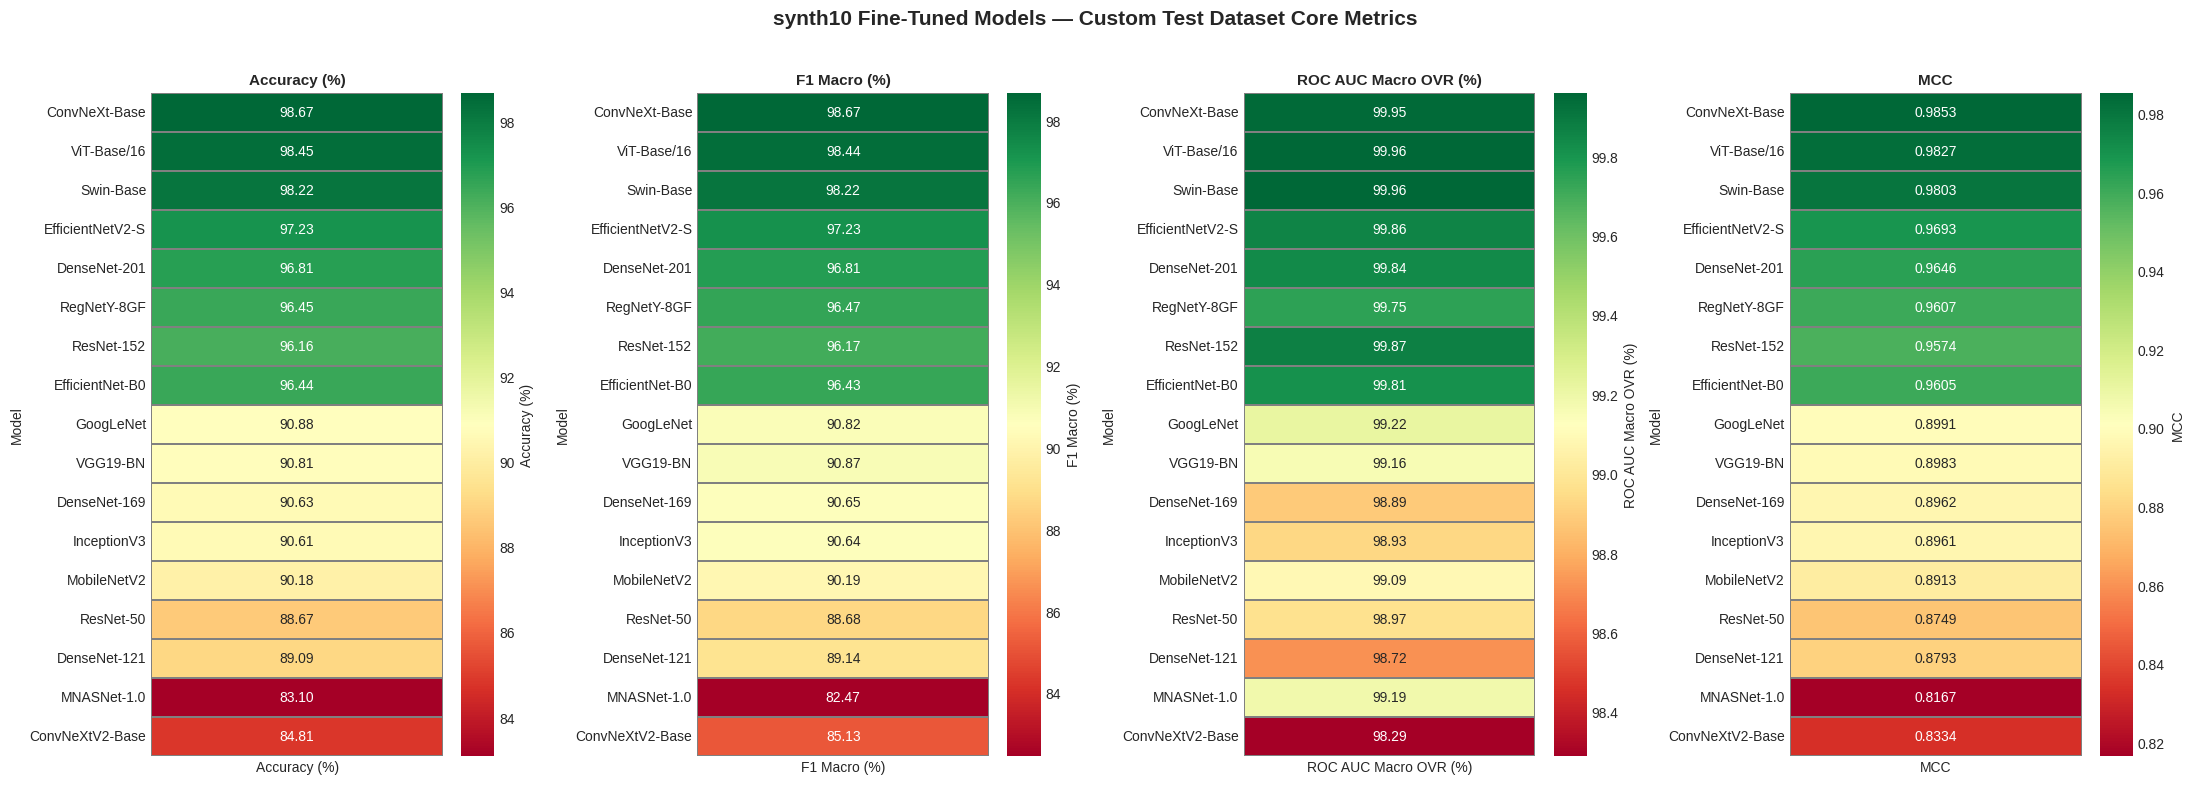

Saved: custom_test_core_metrics_heatmap.png


In [14]:
# ── Core metrics heatmap ──────────────────────────────────────
heat_cols = ['Accuracy (%)', 'F1 Macro (%)', 'ROC AUC Macro OVR (%)', 'MCC']
heat_data = RESULTS_DF.set_index('Model')[heat_cols]

fig, axes = plt.subplots(1, 4, figsize=(22, max(5, len(heat_data) * 0.45)))
fig.suptitle(
    'synth10 Fine-Tuned Models — Custom Test Dataset Core Metrics',
    fontsize=15, fontweight='bold', y=1.02
)

for ax, col in zip(axes, heat_cols):
    fmt = '.4f' if col == 'MCC' else '.2f'
    sns.heatmap(
        heat_data[[col]], annot=True, fmt=fmt, cmap='RdYlGn',
        linewidths=0.3, linecolor='gray',
        cbar_kws={'label': col}, ax=ax
    )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Model')
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('custom_test_core_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: custom_test_core_metrics_heatmap.png')

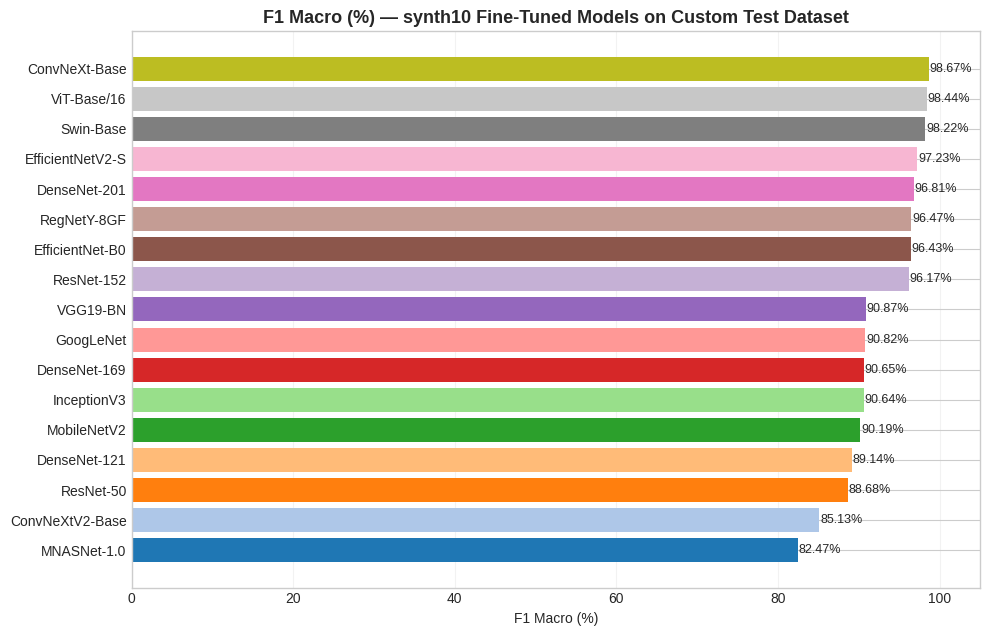

Saved: custom_test_f1_macro_ranking.png


In [15]:
# ── Horizontal bar chart: F1 Macro ranking ────────────────────
plot_df = RESULTS_DF.sort_values('F1 Macro (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.38)))
bars = ax.barh(plot_df['Model'], plot_df['F1 Macro (%)'],
               color=PALETTE[:len(plot_df)])
for bar, val in zip(bars, plot_df['F1 Macro (%)']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', ha='left', fontsize=9)

ax.set_title('F1 Macro (%) — synth10 Fine-Tuned Models on Custom Test Dataset',
             fontsize=13, fontweight='bold')
ax.set_xlabel('F1 Macro (%)')
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('custom_test_f1_macro_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: custom_test_f1_macro_ranking.png')

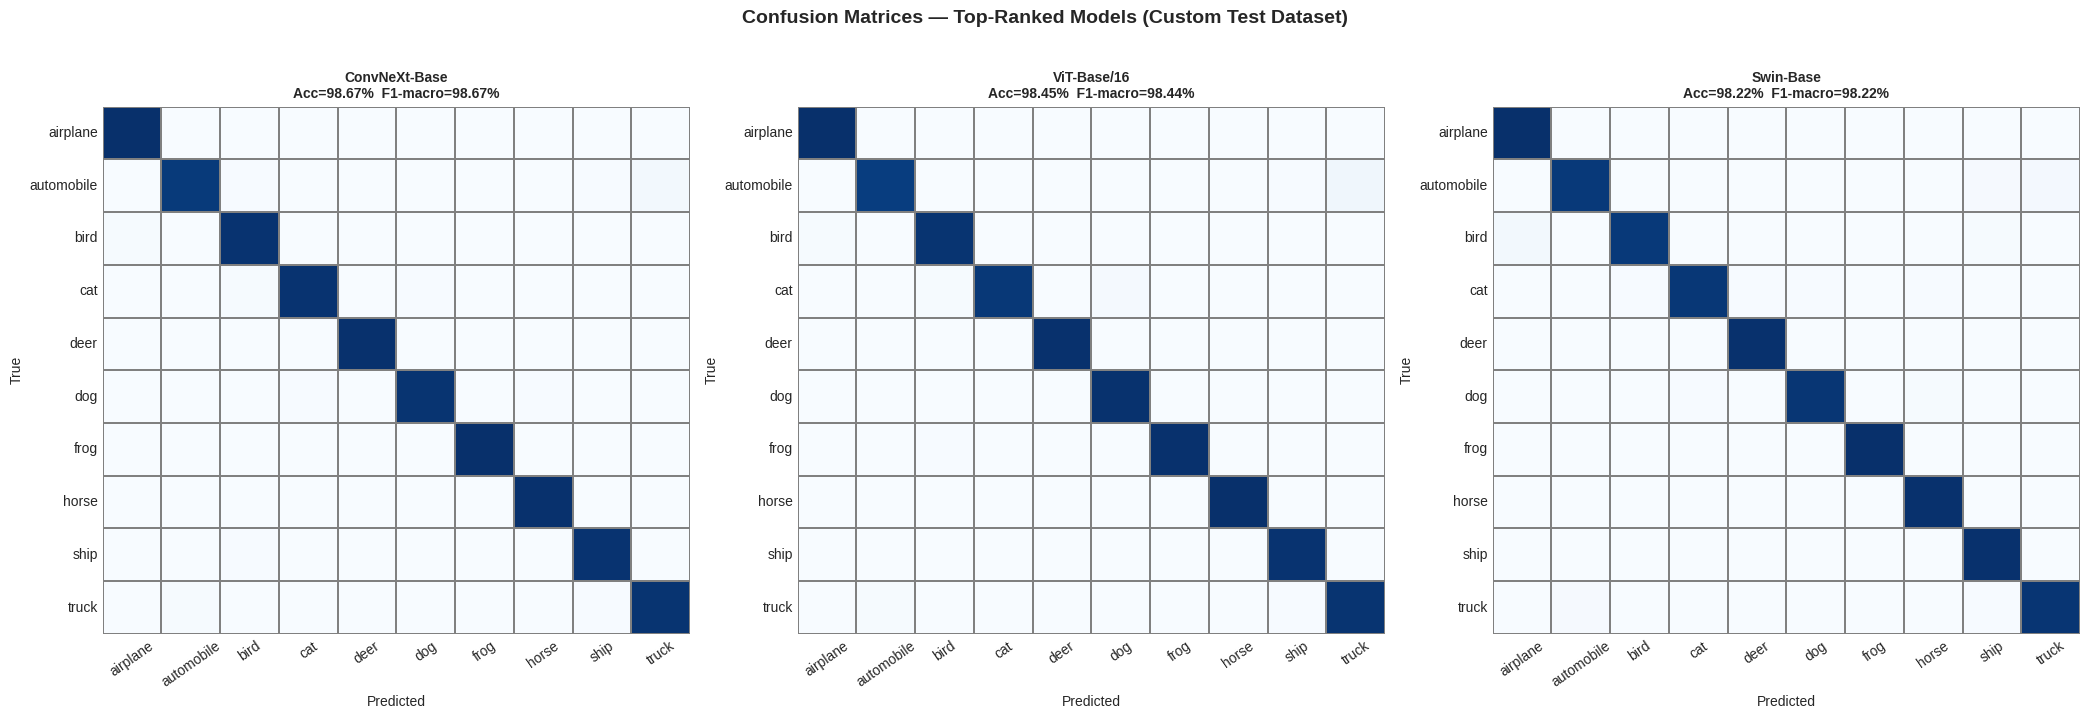

Saved: custom_test_top3_confusion_matrices.png


In [16]:
# ── Confusion matrices for top-3 models ──────────────────────
top3 = RESULTS_DF.head(min(3, len(RESULTS_DF)))['Model'].tolist()
n_plots = len(top3)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 7))
if n_plots == 1:
    axes = [axes]
fig.suptitle('Confusion Matrices — Top-Ranked Models (Custom Test Dataset)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, mname in zip(axes, top3):
    cm_norm = EVAL_RESULTS[mname]['confusion_matrix_norm']
    acc     = EVAL_RESULTS[mname]['accuracy']
    f1m     = EVAL_RESULTS[mname]['f1_macro']

    sns.heatmap(
        cm_norm, annot=False, fmt='.1f', ax=ax,
        xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES,
        cmap='Blues', linewidths=0.2, linecolor='gray',
        cbar=False, vmin=0, vmax=100,
    )
    ax.set_title(f'{mname}\nAcc={acc:.2f}%  F1-macro={f1m:.2f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('custom_test_top3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: custom_test_top3_confusion_matrices.png')

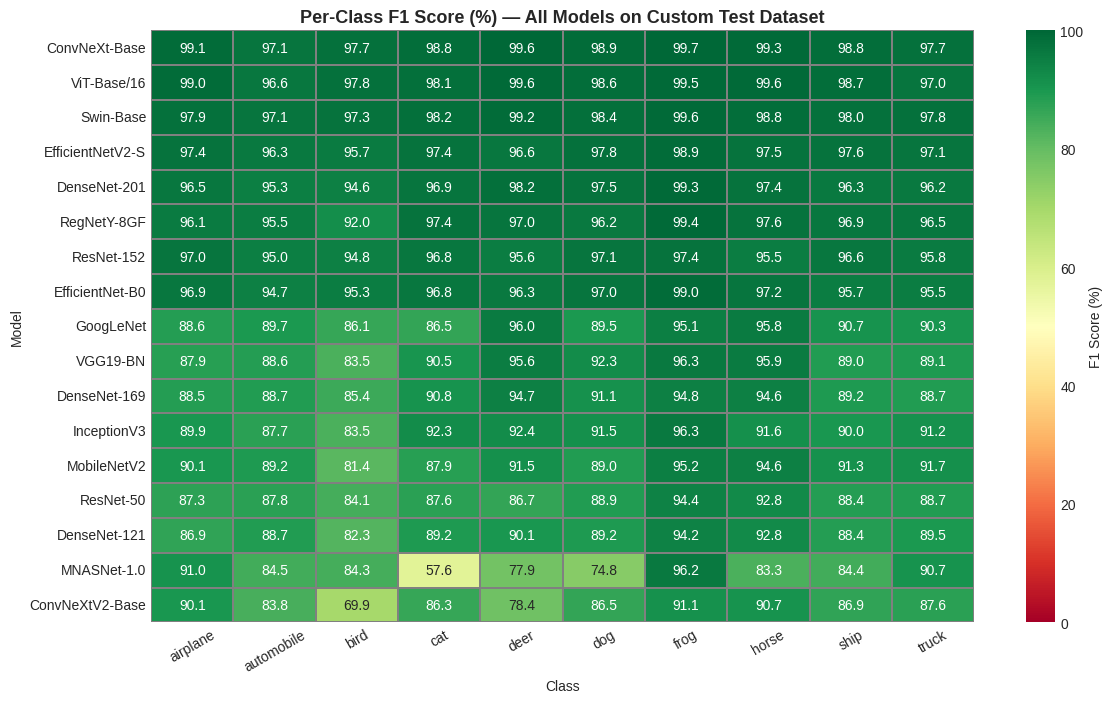

Saved: custom_test_per_class_f1_heatmap.png


In [17]:
# ── Per-class F1 heatmap for all models ──────────────────────
per_class_f1 = pd.DataFrame(
    {name: EVAL_RESULTS[name]['per_class_metrics'].set_index('Class')['F1 Score (%)']
     for name in RESULTS_DF['Model']}
).T   # shape: models × classes

fig, ax = plt.subplots(figsize=(12, max(4, len(per_class_f1) * 0.42)))
sns.heatmap(
    per_class_f1, annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.3, linecolor='gray',
    cbar_kws={'label': 'F1 Score (%)'},
    ax=ax, vmin=0, vmax=100,
)
ax.set_title('Per-Class F1 Score (%) — All Models on Custom Test Dataset',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Model')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('custom_test_per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: custom_test_per_class_f1_heatmap.png')

## 🏆 10 · Summary

In [19]:
print('=' * 90)
print('  synth10 FINE-TUNED MODELS — CUSTOM TEST DATASET EVALUATION SUMMARY')
print('=' * 90)
print(f'  Test dataset root : {TEST_ROOT.resolve()}')
print(f'  Total test images : {total_images}')
print(f'  Models evaluated  : {len(EVAL_RESULTS)}')
print()

best_row = RESULTS_DF.iloc[0]
worst_row = RESULTS_DF.iloc[-1]

print('  BEST MODEL')
print(f'    Name               : {best_row["Model"]}')
print(f'    Accuracy           : {best_row["Accuracy (%)"]:.2f}%')
print(f'    Balanced Accuracy  : {best_row["Balanced Accuracy (%)"]:.2f}%')
print(f'    F1 Macro           : {best_row["F1 Macro (%)"]:.2f}%')
print(f'    ROC AUC Macro OVR  : {best_row["ROC AUC Macro OVR (%)"]:.2f}%')
print(f'    MCC                : {best_row["MCC"]:.4f}')
print(f"    Cohen's Kappa      : {best_row["Cohen's Kappa"]:.4f}")
print()
print('  LOWEST-RANKED MODEL')
print(f'    Name               : {worst_row["Model"]}')
print(f'    Accuracy           : {worst_row["Accuracy (%)"]:.2f}%')
print(f'    F1 Macro           : {worst_row["F1 Macro (%)"]:.2f}%')
print(f'    MCC                : {worst_row["MCC"]:.4f}')
print()
print('  SAVED ARTIFACTS')
for fname in [
    'synth10_finetuned_custom_test_evaluation.csv',
    'custom_test_core_metrics_heatmap.png',
    'custom_test_f1_macro_ranking.png',
    'custom_test_top3_confusion_matrices.png',
    'custom_test_per_class_f1_heatmap.png',
]:
    status = '✅' if Path(fname).exists() else '❌'
    print(f'    {status} {fname}')

print('=' * 90)

  synth10 FINE-TUNED MODELS — CUSTOM TEST DATASET EVALUATION SUMMARY
  Test dataset root : /content/sdxl10
  Total test images : 20000
  Models evaluated  : 17

  BEST MODEL
    Name               : ConvNeXt-Base
    Accuracy           : 98.67%
    Balanced Accuracy  : 98.68%
    F1 Macro           : 98.67%
    ROC AUC Macro OVR  : 99.95%
    MCC                : 0.9853
    Cohen's Kappa      : 0.9853

  LOWEST-RANKED MODEL
    Name               : ConvNeXtV2-Base
    Accuracy           : 84.81%
    F1 Macro           : 85.13%
    MCC                : 0.8334

  SAVED ARTIFACTS
    ✅ synth10_finetuned_custom_test_evaluation.csv
    ✅ custom_test_core_metrics_heatmap.png
    ✅ custom_test_f1_macro_ranking.png
    ✅ custom_test_top3_confusion_matrices.png
    ✅ custom_test_per_class_f1_heatmap.png


In [20]:
# ── Optional: per-class detail for the best model ─────────────
best_name = RESULTS_DF.iloc[0]['Model']
print(f'Per-class metrics for best model: {best_name}\n')
display(
    EVAL_RESULTS[best_name]['per_class_metrics']
    .style.format({
        col: '{:.2f}' for col in [
            'Precision (%)', 'Recall / Sensitivity (%)', 'Specificity (%)',
            'NPV (%)', 'FPR (%)', 'FNR (%)', 'F1 Score (%)'
        ]
    })
)

print('\nTop confusions:')
display(EVAL_RESULTS[best_name]['top_confusions'])

print('\nFull classification report:')
print(EVAL_RESULTS[best_name]['class_report'])

Per-class metrics for best model: ConvNeXt-Base



,Class,Precision (%),Recall / Sensitivity (%),Specificity (%),NPV (%),FPR (%),FNR (%),F1 Score (%),Support
0,airplane,98.42,99.80,99.82,99.98,0.18,0.20,99.11,2000
1,automobile,98.51,95.75,99.84,99.53,0.16,4.25,97.11,2000
2,bird,96.86,98.55,99.64,99.84,0.36,1.45,97.70,2000
3,cat,99.09,98.45,99.90,99.83,0.10,1.55,98.77,2000
4,deer,99.75,99.55,99.97,99.95,0.03,0.45,99.65,2000
5,dog,99.39,98.35,99.93,99.82,0.07,1.65,98.87,2000
6,frog,99.50,99.90,99.94,99.99,0.06,0.10,99.70,2000
7,horse,99.35,99.30,99.93,99.92,0.07,0.70,99.32,2000
8,ship,98.75,98.80,99.86,99.87,0.14,1.20,98.78,2000
9,truck,97.18,98.30,99.68,99.81,0.32,1.70,97.74,2000



Top confusions:


,True Class,Predicted As,Count,Rate (%)
0,automobile,truck,53,2.65
1,cat,bird,21,1.05
2,truck,automobile,21,1.05
3,bird,airplane,19,0.95
4,dog,cat,13,0.65
5,automobile,bird,11,0.55
6,automobile,ship,10,0.50
7,dog,horse,10,0.50
8,ship,bird,9,0.45
9,cat,dog,8,0.40



Full classification report:
              precision    recall  f1-score   support

    airplane     0.9842    0.9980    0.9911      2000
  automobile     0.9851    0.9575    0.9711      2000
        bird     0.9686    0.9855    0.9770      2000
         cat     0.9909    0.9845    0.9877      2000
        deer     0.9975    0.9955    0.9965      2000
         dog     0.9939    0.9835    0.9887      2000
        frog     0.9950    0.9990    0.9970      2000
       horse     0.9935    0.9930    0.9932      2000
        ship     0.9875    0.9880    0.9878      2000
       truck     0.9718    0.9830    0.9774      2000

    accuracy                         0.9868     20000
   macro avg     0.9868    0.9868    0.9867     20000
weighted avg     0.9868    0.9868    0.9867     20000

